# Brain Tumor Segmentation
### Problem Statement:
Manual segmentation of brain tumors is a meticu lous task performed by radiologists, which is time consuming and prone to inter-observer variability. In clinical practice, high precision is required to ensure effective treatment. However, processing 3D medical images presents significant computational challenges due to high dimensionality and class imbalance. Furthermore, to be adopted in clinical workflows, these models must demonstrate transparency in their diagnostic outputs.

### Data:
The project will utilize the [BraTS 2021](https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1/data) Task 1
Database, which contains 3D MRI scans for 1,251
subjects.

### Objective:
* Develop a 3D Deep Learning Model to pre
dict voxel-wise segmentation masks from volumet
ric MRI data.
* Classify brain tissue into four categories: healthy
tissue, necrotic core, peritumoral edema, and en
hancing tumor.
* Evaluate the model using standardized clinical
metrics and visualize results to ensure anatomical
accuracy

### Expected Outcomes:
* High segmentation accuracy across all target re
gions (Whole Tumor, Tumor Core, and Enhancing
Tumor).
* A reliable, automated pipeline to assist in clinical
decision-making.

### Install Requirted packages...
We used python 3.12.10, pytorch 2.10.0 opencv-python 4.13, scikit-image 0.26.0,  scikit-learn 1.6.1, matplotlib 3.10.8, pandas 3.0.1.

We use **MONAI**, a PyTorch-based framework purpose-built for medical image analysis. It provides 3D transforms, volumetric data loaders, segmentation architectures, and clinical metrics out of the box.

## Environment

| Package | Version | Purpose |
|---|---|---|
| **Python** | 3.12.10 | Programming language |
| **torch** | 2.10.0 | Deep learning framework (3D U-Net, Attention U-Net, Swin UNETR) |
| **torchvision** | 0.25.0 | Vision utilities, paired with torch |
| **torchaudio** | 2.10.0 | Audio utilities, paired with torch |
| **CUDA** | 13.0 | GPU acceleration backend |
| **monai** | >=1.4 (all) | Medical image segmentation models, transforms, losses |
| **nibabel** | latest | Loading NIfTI (.nii.gz) MRI volumes from BraTS 2021 |
| **matplotlib** | 3.10.8 | Visualization of MRI slices and training curves |
| **numpy** | latest | Numerical array operations |
| **pandas** | 3.0.1 | Data management and results logging |
| **scikit-learn** | 1.6.1 | Evaluation metrics and data splitting |
| **tqdm** | latest | Progress bars for training loops |
| **tensorboard** | latest | Training metrics logging and visualization |


## Importing Libraries

In [27]:
import os
import glob
import time
import json
import random
import warnings
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

import monai
from monai.data import Dataset, DataLoader, decollate_batch, CacheDataset
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    NormalizeIntensityd,
    CropForegroundd,
    RandSpatialCropd,
    RandFlipd,
    RandRotate90d,
    RandScaleIntensityd,
    RandShiftIntensityd,
    EnsureTyped,
    Activationsd,
    AsDiscreted,
    SpatialPadd,
)
from monai.networks.nets import UNet, AttentionUnet, SwinUNETR
from monai.losses import DiceLoss, DiceCELoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism

warnings.filterwarnings("ignore")

print(f"Python:  {__import__('sys').version}")
print(f"PyTorch: {torch.__version__}")
print(f"MONAI:   {monai.__version__}")
print(f"CUDA:    {torch.cuda.is_available()} "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'})")

Python:  3.12.1 | packaged by Anaconda, Inc. | (main, Jan 19 2024, 15:44:08) [MSC v.1916 64 bit (AMD64)]
PyTorch: 2.10.0+cu130
MONAI:   1.5.2
CUDA:    True (NVIDIA GeForce RTX 5070 Ti Laptop GPU)


## Configuration & Reproducibility
All hyperparameters live in one dictionary so you can tweak them without hunting through the notebook.

In [28]:
set_determinism(seed=42)

CONFIG = {
    # ── Paths ──────────────────────────────────────────────────
    "data_dir":    "data/brats2021",

    # ── Training ──────────────────────────────────────────────
    "max_epochs":     100,
    "batch_size":     2,       # reduce to 1 if GPU memory is tight
    "learning_rate":  1e-4,
    "weight_decay":   1e-5,
    "val_interval":   2,       # run validation every N epochs
    "patience":       15,      # early-stopping patience (in val intervals)

    # ── Data ──────────────────────────────────────────────────
    "roi_size":       (128, 128, 128),  # 3D crop/patch size
    "num_workers":    0,
    "cache_rate":     0.1,     # fraction of data to cache in RAM

    # ── Model ─────────────────────────────────────────────────
    "in_channels":    4,       # T1, T1ce, T2, FLAIR
    "num_classes":    4,       # background + 3 tumor sub-regions
    "model_name":     "unet",  # options: "unet", "attention_unet", "swin_unetr"
}

# Auto-set output directory based on model name — prevents overwriting
CONFIG["output_dir"] = f"./outputs/{CONFIG['model_name']}"
os.makedirs(CONFIG["output_dir"], exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device:     {device}")
print(f"Model:            {CONFIG['model_name']}")
print(f"Output directory: {CONFIG['output_dir']}")
print(f"Max epochs: {CONFIG['max_epochs']}")
print(f"Exists:     {os.path.exists(CONFIG['output_dir'])}")

Using device:     cuda
Model:            unet
Output directory: ./outputs/unet
Max epochs: 100
Exists:     True


### Discover & Organize Data Paths

BraTS 2021 stores each subject in its own folder with four MRI modality files and one segmentation mask:

```
BraTS2021_00000/
    BraTS2021_00000_t1.nii.gz
    BraTS2021_00000_t1ce.nii.gz
    BraTS2021_00000_t2.nii.gz
    BraTS2021_00000_flair.nii.gz
    BraTS2021_00000_seg.nii.gz
```

We build a list of dictionaries — one per subject — that MONAI's data pipeline can consume directly.

In [29]:
def build_file_list(data_dir: str) -> list[dict]:
    """Scan data_dir and return a list of dicts with keys:
       't1', 't1ce', 't2', 'flair', 'seg' — each mapping to a file path."""
    subjects = sorted(glob.glob(os.path.join(data_dir, "BraTS2021_*")))
    data_dicts = []
    for subj in subjects:
        subj_id = os.path.basename(subj)
        entry = {
            "t1":    os.path.join(subj, f"{subj_id}_t1.nii.gz"),
            "t1ce":  os.path.join(subj, f"{subj_id}_t1ce.nii.gz"),
            "t2":    os.path.join(subj, f"{subj_id}_t2.nii.gz"),
            "flair": os.path.join(subj, f"{subj_id}_flair.nii.gz"),
            "seg":   os.path.join(subj, f"{subj_id}_seg.nii.gz"),
        }
        # Sanity check — all files must exist
        if all(os.path.isfile(v) for v in entry.values()):
            data_dicts.append(entry)
        else:
            print(f"Warning: Skipping {subj_id} — missing files")
    return data_dicts

all_data = build_file_list(CONFIG["data_dir"])
print(f"Total subjects found: {len(all_data)}")

Total subjects found: 1251


### Train / Validation / Test Split (80 / 10 / 10)

We use random splitting (deterministic via seed). With 1,251 subjects this gives roughly 1,000 / 125 / 126.

In [30]:
train_val_data, test_data = train_test_split(all_data, test_size=0.10, random_state=42)
train_data, val_data = train_test_split(train_val_data, test_size=0.1111, random_state=42)
# 0.1111 of 90% is approx 10% of total

print(f"Train : {len(train_data)} subjects")
print(f"Val   : {len(val_data)} subjects")
print(f"Test  : {len(test_data)} subjects")

Train : 1000 subjects
Val   : 125 subjects
Test  : 126 subjects


### Explore a Single Subject

Before building the pipeline, let's look at the raw data: shapes, voxel sizes, intensity ranges, and label distributions. This helps verify the data is loaded correctly.

In [31]:
sample = all_data[0]

print("=== Sample Subject ===")
for key in ["t1", "t1ce", "t2", "flair", "seg"]:
    img = nib.load(sample[key])
    data = img.get_fdata()
    print(f"{key:>5s}  shape={str(data.shape):>20s}  "
          f"dtype={str(data.dtype):>10s}  "
          f"range=[{data.min():.1f}, {data.max():.1f}]  "
          f"voxel_size={np.array(img.header.get_zooms()[:3]).round(2)}")

# Label distribution
seg = nib.load(sample["seg"]).get_fdata()
unique, counts = np.unique(seg, return_counts=True)
print("\nLabel distribution:")
label_names = {0: "Background", 1: "NCR/NET", 2: "Edema", 4: "Enhancing"}
for u, c in zip(unique, counts):
    pct = 100.0 * c / seg.size
    print(f"  Label {int(u)} ({label_names.get(int(u), '?'):>12s}): "
          f"{c:>10,} voxels ({pct:.2f}%)")

=== Sample Subject ===
   t1  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 2023.0]  voxel_size=[1. 1. 1.]
 t1ce  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 12343.0]  voxel_size=[1. 1. 1.]
   t2  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 2421.0]  voxel_size=[1. 1. 1.]
flair  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 2934.0]  voxel_size=[1. 1. 1.]
  seg  shape=     (240, 240, 155)  dtype=   float64  range=[0.0, 4.0]  voxel_size=[1. 1. 1.]

Label distribution:
  Label 0 (  Background):  8,870,695 voxels (99.36%)
  Label 1 (     NCR/NET):     11,738 voxels (0.13%)
  Label 2 (       Edema):     12,836 voxels (0.14%)
  Label 4 (   Enhancing):     32,731 voxels (0.37%)


### Visualize Raw MRI Slices + Segmentation Overlay

Display the four MRI modalities and the ground-truth segmentation mask at the axial slice with the most tumor content. This gives an intuitive sense of what each modality highlights.

- **T1/T1ce:** Structural detail, tumor core visibility
- **T2/FLAIR:** Best for identifying peritumoral edema
- **Colors:** Red = NCR/NET, Green = Edema, Yellow = Enhancing tumor

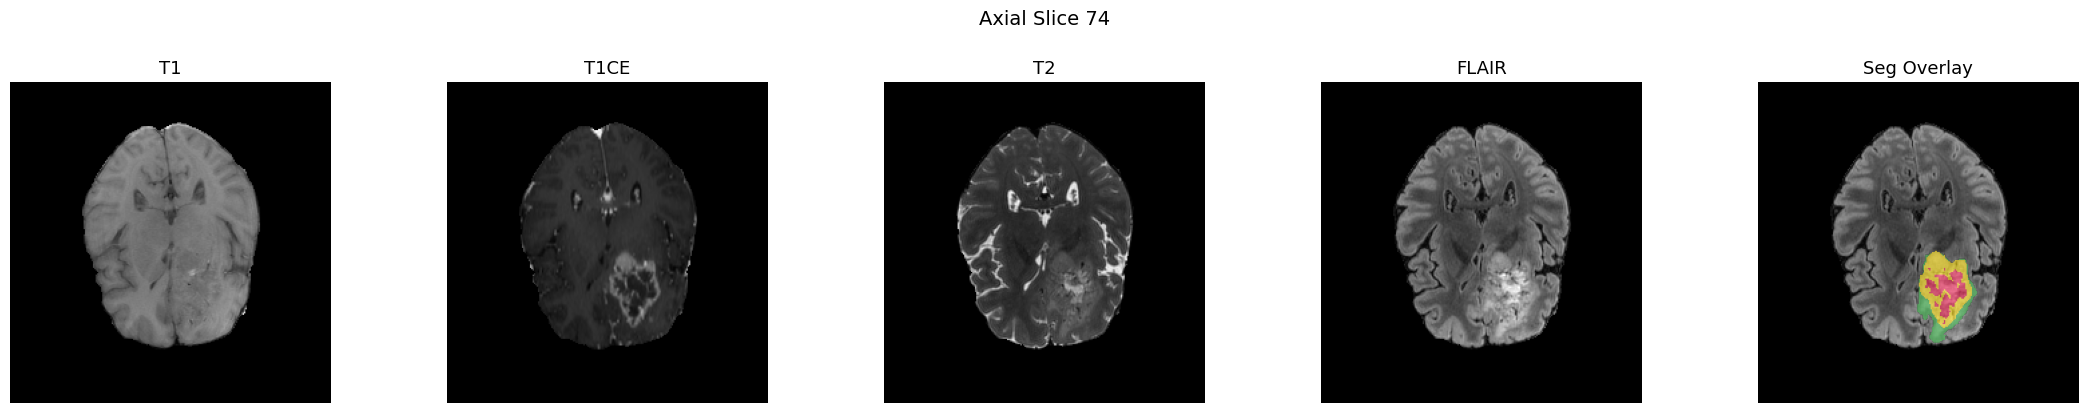

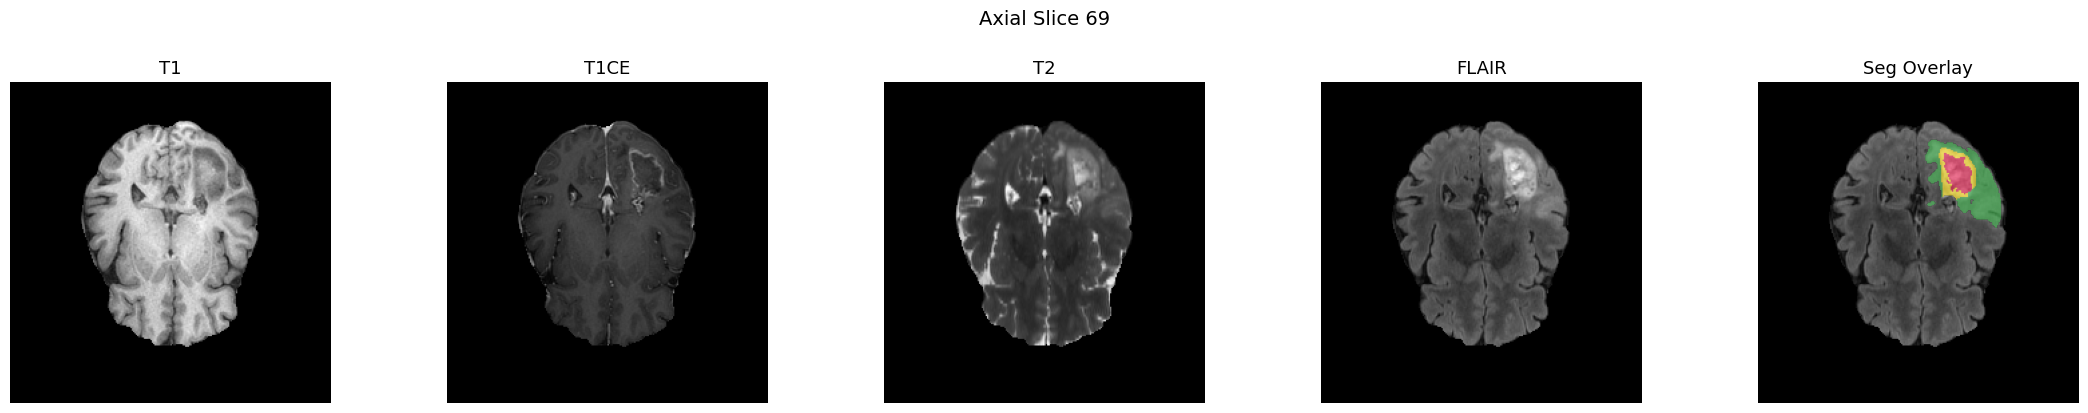

In [32]:
def visualize_subject(subject_dict: dict, slice_idx: int | None = None):
    """Plot 4 MRI modalities + segmentation overlay for one subject."""
    modalities = ["t1", "t1ce", "t2", "flair"]
    images = {k: nib.load(subject_dict[k]).get_fdata() for k in modalities}
    seg = nib.load(subject_dict["seg"]).get_fdata()

    if slice_idx is None:
        # Find axial slice with maximum tumor content
        tumor_per_slice = (seg > 0).sum(axis=(0, 1))
        slice_idx = int(np.argmax(tumor_per_slice))

    seg_cmap = ListedColormap(["none", "#e6194b", "#3cb44b", "black", "#ffe119"])

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for ax, mod in zip(axes[:4], modalities):
        ax.imshow(images[mod][:, :, slice_idx].T, cmap="gray", origin="lower")
        ax.set_title(mod.upper(), fontsize=13)
        ax.axis("off")

    # Overlay: FLAIR + segmentation
    axes[4].imshow(images["flair"][:, :, slice_idx].T, cmap="gray", origin="lower")
    seg_masked = np.ma.masked_where(
        seg[:, :, slice_idx].T == 0, seg[:, :, slice_idx].T
    )
    axes[4].imshow(seg_masked, cmap=seg_cmap, alpha=0.6, origin="lower", vmin=0, vmax=4)
    axes[4].set_title("Seg Overlay", fontsize=13)
    axes[4].axis("off")

    plt.suptitle(f"Axial Slice {slice_idx}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize two different subjects
visualize_subject(all_data[0])
visualize_subject(all_data[10])

### Custom Transform: Remap BraTS Labels

BraTS uses labels `{0, 1, 2, 4}` — label 3 is absent. We remap them to contiguous class indices `{0, 1, 2, 3}` so that standard cross-entropy and softmax (which expect classes 0..N-1) work correctly.

| Original | Remapped | Region |
|----------|----------|--------|
| 0 | 0 | Background |
| 1 | 1 | NCR/NET |
| 2 | 2 | Edema |
| 4 | 3 | Enhancing |

In [33]:
class ConvertBraTSLabels(monai.transforms.MapTransform):
    """Remap BraTS labels {0,1,2,4} -> {0,1,2,3}."""

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = d[key].clone() if isinstance(d[key], torch.Tensor) else d[key].copy()
            d[key][d[key] == 4] = 3
        return d

print("ConvertBraTSLabels transform defined.")

ConvertBraTSLabels transform defined.


### Custom Transform: Stack Modalities

The four MRI modalities are loaded as separate dictionary keys. We stack them into a single `(4, D, H, W)` tensor under the key `"image"`, and squeeze the segmentation to `(D, H, W)` integer labels.

In [34]:
class StackModalities(monai.transforms.MapTransform):
    """Stack T1, T1ce, T2, FLAIR into a single 4-channel volume under key 'image'.
       Also convert seg from (1,D,H,W) to (D,H,W) integer labels."""

    def __init__(self, image_keys, seg_key="seg"):
        super().__init__(keys=image_keys)
        self.image_keys = image_keys
        self.seg_key = seg_key

    def __call__(self, data):
        d = dict(data)
        # Stack: each modality is (1, D, H, W) -> combined (4, D, H, W)
        d["image"] = torch.cat([d[k] for k in self.image_keys], dim=0)
        # Seg: (1, D, H, W) -> (D, H, W) as long tensor
        d["seg"] = d[self.seg_key][0].long()
        # Remove individual modality keys
        for k in self.image_keys:
            del d[k]
        return d

print("StackModalities transform defined.")

StackModalities transform defined.


### Build MONAI Transform Pipelines

**Training transforms** include data augmentation (random crops, flips, rotations, intensity perturbations) to improve generalization.

**Validation/test transforms** are deterministic — no augmentation.

Key preprocessing steps:
- **Orientation -> RAS**: consistent axis ordering across all scans
- **Spacing -> 1mm isotropic**: uniform resolution via resampling
- **Z-score normalization**: per-channel, nonzero voxels only (brain MRI standard)
- **Foreground crop**: removes large empty margins to reduce computation

In [35]:
image_keys = ["t1", "t1ce", "t2", "flair"]
all_keys = image_keys + ["seg"]

# ── Training transforms (with augmentation) ────────────────────
train_transforms = Compose([
    # Load NIfTI files
    LoadImaged(keys=all_keys),
    EnsureChannelFirstd(keys=all_keys),

    # Spatial standardization
    Orientationd(keys=all_keys, axcodes="RAS"),
    Spacingd(
        keys=all_keys,
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear",) * 4 + ("nearest",),  # nearest for seg
    ),

    # Remap labels: {0,1,2,4} -> {0,1,2,3}
    ConvertBraTSLabels(keys="seg"),

    # Intensity normalization (per-channel, nonzero only)
    NormalizeIntensityd(keys=image_keys, nonzero=True, channel_wise=True),

    # Crop out empty background margins
    CropForegroundd(keys=all_keys, source_key="t1ce", margin=10),

   # Pad to minimum size (in case foreground crop made it smaller than roi_size)
    SpatialPadd(keys=all_keys, spatial_size=CONFIG["roi_size"], mode="constant"),

    # Random 3D crop to patch size
    RandSpatialCropd(
        keys=all_keys,
        roi_size=CONFIG["roi_size"],
        random_center=True,
        random_size=False,
    ),

    # Augmentation — spatial
    RandFlipd(keys=all_keys, prob=0.5, spatial_axis=0),
    RandFlipd(keys=all_keys, prob=0.5, spatial_axis=1),
    RandFlipd(keys=all_keys, prob=0.5, spatial_axis=2),
    RandRotate90d(keys=all_keys, prob=0.5, max_k=3),

    # Augmentation — intensity
    RandScaleIntensityd(keys=image_keys, factors=0.1, prob=0.5),
    RandShiftIntensityd(keys=image_keys, offsets=0.1, prob=0.5),

    # Convert to tensors
    EnsureTyped(keys=all_keys, dtype=torch.float32),

    # Stack 4 modalities into single image tensor
    StackModalities(image_keys=image_keys),
])

# ── Validation / Test transforms (no augmentation) ────────────
val_transforms = Compose([
    LoadImaged(keys=all_keys),
    EnsureChannelFirstd(keys=all_keys),
    Orientationd(keys=all_keys, axcodes="RAS"),
    Spacingd(
        keys=all_keys,
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear",) * 4 + ("nearest",),
    ),
    ConvertBraTSLabels(keys="seg"),
    NormalizeIntensityd(keys=image_keys, nonzero=True, channel_wise=True),
    CropForegroundd(keys=all_keys, source_key="t1ce", margin=10),
    EnsureTyped(keys=all_keys, dtype=torch.float32),
    StackModalities(image_keys=image_keys),
])

print("Transform pipelines defined.")

Transform pipelines defined.


### Create Datasets & DataLoaders

`CacheDataset` with `runtime_cache="threads"` caches data lazily — each subject is cached the first time it's accessed. Epoch 1 is slow (loading from disk), but subsequent epochs are fast (served from RAM). Memory grows gradually instead of all at once.

In [36]:
train_ds = CacheDataset(
    data=train_data,
    transform=train_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=0,
    runtime_cache="threads",
)
val_ds = CacheDataset(
    data=val_data,
    transform=val_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=0,
    runtime_cache="threads",
)
test_ds = CacheDataset(
    data=test_data,
    transform=val_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=0,
    runtime_cache="threads",
)

train_loader = DataLoader(
    train_ds, batch_size=CONFIG["batch_size"],
    shuffle=True, num_workers=0, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=1, shuffle=False,
    num_workers=0, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=False,
    num_workers=0, pin_memory=True,
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val subjects:  {len(val_loader)}")
print(f"Test subjects: {len(test_loader)}")

Train batches per epoch: 500
Val subjects:  125
Test subjects: 126


### Verify a Training Batch

Load one batch and verify the shapes and value ranges are correct before training.

In [37]:
sample_batch = next(iter(train_loader))

print(f"Image shape : {sample_batch['image'].shape}")    # (B, 4, 128, 128, 128)
print(f"Seg shape   : {sample_batch['seg'].shape}")      # (B, 128, 128, 128)
print(f"Image dtype : {sample_batch['image'].dtype}")
print(f"Seg dtype   : {sample_batch['seg'].dtype}")
print(f"Image range : [{sample_batch['image'].min():.2f}, {sample_batch['image'].max():.2f}]")
print(f"Seg labels  : {torch.unique(sample_batch['seg']).tolist()}")

Image shape : torch.Size([2, 4, 128, 128, 128])
Seg shape   : torch.Size([2, 128, 128, 128])
Image dtype : torch.float32
Seg dtype   : torch.int64
Image range : [-3.71, 15.84]
Seg labels  : [0, 1, 2, 3]


### Visualize a Preprocessed Training Patch

Show the four channels of a randomly cropped & augmented training patch alongside its segmentation mask.

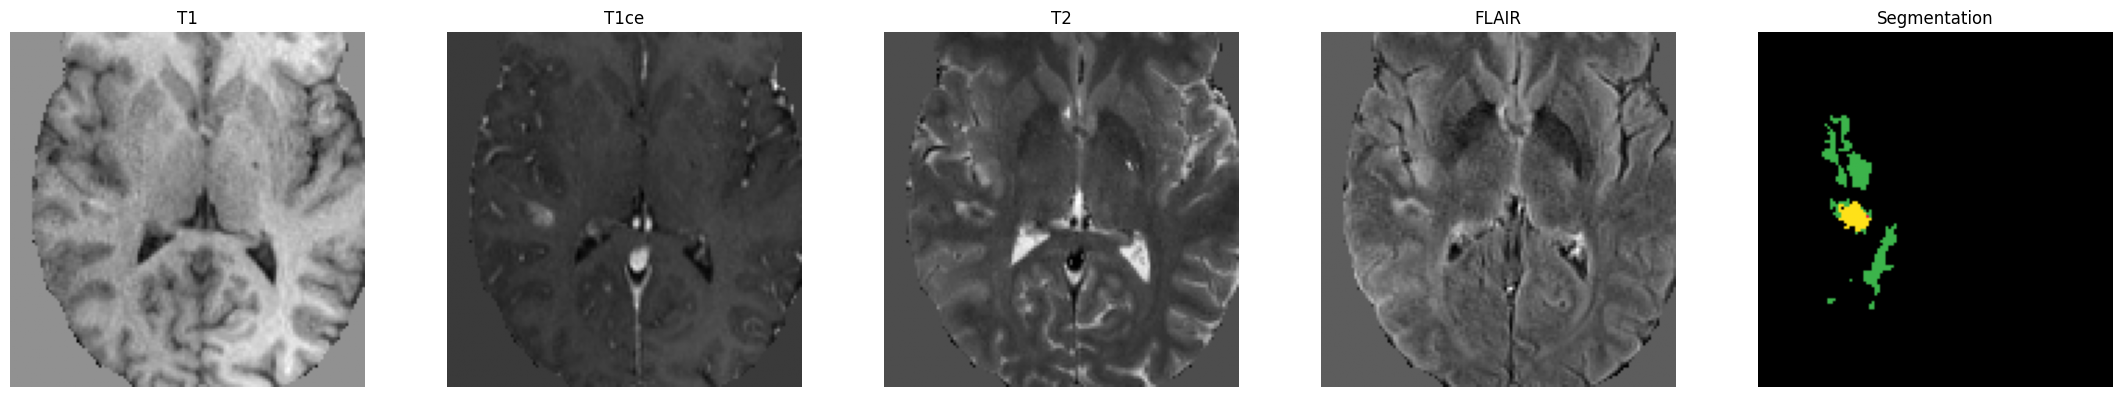

In [38]:
def show_training_patch(batch, sample_idx=0, slice_idx=64):
    """Visualize a single training patch."""
    img = batch["image"][sample_idx].cpu().numpy()   # (4, D, H, W)
    seg = batch["seg"][sample_idx].cpu().numpy()     # (D, H, W)

    titles = ["T1", "T1ce", "T2", "FLAIR", "Segmentation"]
    seg_cmap = ListedColormap(["black", "#e6194b", "#3cb44b", "#ffe119"])

    fig, axes = plt.subplots(1, 5, figsize=(22, 4))
    for i in range(4):
        axes[i].imshow(img[i, :, :, slice_idx].T, cmap="gray", origin="lower")
        axes[i].set_title(titles[i])
        axes[i].axis("off")

    axes[4].imshow(seg[:, :, slice_idx].T, cmap=seg_cmap,
                   origin="lower", vmin=0, vmax=3)
    axes[4].set_title("Segmentation")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()

show_training_patch(sample_batch)

### Define Model Architectures

We provide three architectures from the proposal. Switch between them by changing `CONFIG["model_name"]`.

**3D U-Net** — The workhorse for volumetric segmentation. Encoder-decoder with skip connections combining spatial detail and semantic features.

**Attention U-Net** — Adds attention gates to skip connections, learning to focus on small, hard-to-segment regions like enhancing tumor.

**Swin UNETR** — Shifted-Window Transformer encoder + CNN decoder. Captures long-range spatial dependencies but needs more GPU memory (~16+ GB).

In [39]:
def build_model(config: dict, device: torch.device) -> nn.Module:
    """Instantiate the chosen model architecture."""
    name = config["model_name"].lower()

    if name == "unet":
        model = UNet(
            spatial_dims=3,
            in_channels=config["in_channels"],
            out_channels=config["num_classes"],
            channels=(32, 64, 128, 256, 512),
            strides=(2, 2, 2, 2),
            num_res_units=2,
            dropout=0.2,
        )

    elif name == "attention_unet":
        model = AttentionUnet(
            spatial_dims=3,
            in_channels=config["in_channels"],
            out_channels=config["num_classes"],
            channels=(32, 64, 128, 256, 512),
            strides=(2, 2, 2, 2),
            dropout=0.2,
        )

    elif name == "swin_unetr":
        model = SwinUNETR(
            img_size=config["roi_size"],
            in_channels=config["in_channels"],
            out_channels=config["num_classes"],
            feature_size=48,
            drop_rate=0.0,
            attn_drop_rate=0.0,
            dropout_path_rate=0.0,
            use_v2=True,
        )
    else:
        raise ValueError(f"Unknown model: {name}. Choose 'unet', 'attention_unet', or 'swin_unetr'.")

    model = model.to(device)
    total_params = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model: {name}")
    print(f"  Total parameters:     {total_params:,}")
    print(f"  Trainable parameters: {trainable:,}")
    return model

model = build_model(CONFIG, device)

Model: unet
  Total parameters:     19,225,897
  Trainable parameters: 19,225,897


### Loss Function, Optimizer & Scheduler

**Dice-CE Loss** combines:
- **Dice Loss**: directly optimizes spatial overlap — excellent for class imbalance
- **Cross-Entropy Loss**: provides stable per-voxel gradients for smooth convergence

This combination is the standard for BraTS segmentation challenges.

**AdamW** optimizer with **Cosine Annealing** LR schedule smoothly reduces the learning rate for fine-grained convergence.

In [40]:
# Combined Dice + Cross-Entropy loss
loss_fn = DiceCELoss(
    to_onehot_y=True,            # auto one-hot encode the labels
    softmax=True,                # apply softmax to model outputs
    include_background=False,    # exclude background from Dice (focus on tumor)
    lambda_dice=1.0,
    lambda_ce=1.0,
)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
)

# LR scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG["max_epochs"],
    eta_min=1e-7,
)

print("Loss function, optimizer, and LR scheduler configured.")

Loss function, optimizer, and LR scheduler configured.


### Evaluation Metrics

We compute metrics on three clinically relevant regions:

| Region | Remapped Labels | Clinical Meaning |
|--------|----------------|------------------|
| Whole Tumor (WT) | 1 + 2 + 3 | Total tumor extent |
| Tumor Core (TC) | 1 + 3 | Solid tumor (no edema) |
| Enhancing Tumor (ET) | 3 | Active/contrast-enhancing tumor |

**Dice Similarity Coefficient (DSC):** Overlap metric. 1.0 = perfect segmentation.

**95th-Percentile Hausdorff Distance (HD95):** Worst-case boundary error (excluding outlier 5%). Lower is better, measured in mm.

In [41]:
hd95_metric = HausdorffDistanceMetric(
    include_background=False, percentile=95, reduction="mean"
)


def compute_dice_per_channel(pred: torch.Tensor, target: torch.Tensor,
                             smooth: float = 1e-5) -> np.ndarray:
    """Compute Dice score for each channel manually.
    
    Args:
        pred:   (B, C, D, H, W) binary predictions
        target: (B, C, D, H, W) binary ground truth
    Returns:
        numpy array of shape (C,) with Dice per channel
    """
    num_channels = pred.shape[1]
    dice_scores = []
    for c in range(num_channels):
        p = pred[:, c].float().flatten()
        t = target[:, c].float().flatten()
        intersection = (p * t).sum()
        union = p.sum() + t.sum()
        if union < smooth:  # both pred and GT are empty
            dice_scores.append(1.0)  # perfect match (both empty)
        else:
            dice_scores.append(((2.0 * intersection + smooth) / (union + smooth)).item())
    return np.array(dice_scores)


def compute_brats_regions(pred: torch.Tensor, seg: torch.Tensor):
    """Convert per-class predictions to BraTS clinical regions.

    Args:
        pred: (B, D, H, W) integer class predictions (0-3)
        seg:  (B, D, H, W) integer ground truth (0-3)

    Returns:
        pred_regions, seg_regions: each (B, 3, D, H, W) binary tensors
        for channels [WT, TC, ET]
    """
    def to_regions(x):
        if x.dim() == 3:
            x = x.unsqueeze(0)
        wt = (x >= 1).float()                   # labels 1 + 2 + 3
        tc = ((x == 1) | (x == 3)).float()      # labels 1 + 3
        et = (x == 3).float()                   # label 3 only
        return torch.stack([wt, tc, et], dim=1)  # (B, 3, D, H, W)

    return to_regions(pred), to_regions(seg)


print("Metrics defined.")

Metrics defined.


### Training Loop

The training loop includes:
- **Mixed-precision training** (`torch.amp`) — 2x faster, 30-50% less GPU memory
- **Gradient clipping** — stabilizes training on medical imaging tasks
- **Sliding-window inference** for validation — processes full-resolution volumes without running out of memory
- **Early stopping** — halts training when validation Dice stops improving
- **TensorBoard logging** — track loss and Dice curves
- **Best model checkpointing** — saves the best weights automatically

In [42]:
def train(model, train_loader, val_loader, loss_fn, optimizer, scheduler,
          config, device):
    """Full training loop with validation, early stopping, and logging."""

    writer = SummaryWriter(log_dir=os.path.join(config["output_dir"], "tb_logs"))
    best_metric = -1.0
    best_epoch = -1
    epochs_no_improve = 0
    scaler = torch.amp.GradScaler("cuda")

    history = {
        "train_loss": [],
        "val_dice_wt": [], "val_dice_tc": [], "val_dice_et": [],
        "val_mean_dice": [],
    }

    for epoch in range(config["max_epochs"]):
        # ────────────── Training ──────────────────────────────
        model.train()
        epoch_loss = 0.0
        step_count = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['max_epochs']}")
        for batch in pbar:
            images = batch["image"].to(device)
            labels = batch["seg"].to(device).unsqueeze(1)

            optimizer.zero_grad()

            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = loss_fn(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            step_count += 1
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_loss = epoch_loss / step_count
        history["train_loss"].append(avg_loss)
        writer.add_scalar("Loss/train", avg_loss, epoch)
        writer.add_scalar("LR", scheduler.get_last_lr()[0], epoch)
        scheduler.step()

        # ────────────── Validation ────────────────────────────
        if (epoch + 1) % config["val_interval"] == 0:
            model.eval()
            val_dice_list = []

            with torch.no_grad():
                for val_batch in val_loader:
                    val_images = val_batch["image"].to(device)
                    val_labels = val_batch["seg"].to(device)

                    with torch.amp.autocast("cuda"):
                        val_outputs = sliding_window_inference(
                            inputs=val_images,
                            roi_size=config["roi_size"],
                            sw_batch_size=2,
                            predictor=model,
                            overlap=0.5,
                        )

                    val_pred = torch.argmax(val_outputs, dim=1)
                    pred_regions, seg_regions = compute_brats_regions(
                        val_pred, val_labels
                    )

                    # Manual per-subject dice — always returns 3 values
                    subj_dice = compute_dice_per_channel(pred_regions, seg_regions)
                    val_dice_list.append(subj_dice)

            dice_vals = np.mean(val_dice_list, axis=0)  # (3,)
            dice_wt, dice_tc, dice_et = dice_vals[0], dice_vals[1], dice_vals[2]
            mean_dice = dice_vals.mean()

            history["val_dice_wt"].append(dice_wt)
            history["val_dice_tc"].append(dice_tc)
            history["val_dice_et"].append(dice_et)
            history["val_mean_dice"].append(mean_dice)

            writer.add_scalar("Dice/WT", dice_wt, epoch)
            writer.add_scalar("Dice/TC", dice_tc, epoch)
            writer.add_scalar("Dice/ET", dice_et, epoch)
            writer.add_scalar("Dice/Mean", mean_dice, epoch)

            print(f"  Val — Mean Dice: {mean_dice:.4f}  "
                  f"[WT: {dice_wt:.4f}  TC: {dice_tc:.4f}  ET: {dice_et:.4f}]")

            if mean_dice > best_metric:
                best_metric = mean_dice
                best_epoch = epoch + 1
                epochs_no_improve = 0
                ckpt_path = os.path.join(config["output_dir"], "best_model.pth")
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_dice": best_metric,
                    "config": config,
                }, ckpt_path)
                print(f"  >> New best model saved (Dice={best_metric:.4f})")
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= config["patience"]:
                print(f"\nEarly stopping at epoch {epoch+1} "
                      f"(no improvement for {config['patience']} val intervals)")
                break

    writer.close()
    print(f"\nTraining complete. Best Mean Dice: {best_metric:.4f} at epoch {best_epoch}")
    return history

### Run Training

Execute the training loop. On a single GPU (e.g. RTX 5070) with `batch_size=2`, expect roughly 15-30 minutes per epoch on the full dataset.


In [19]:
history = train(model, train_loader, val_loader, loss_fn, optimizer,
                scheduler, CONFIG, device)

Epoch 1/100:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/500 [00:00<?, ?it/s]

  Val — Mean Dice: 0.7669  [WT: 0.8511  TC: 0.7298  ET: 0.7199]
  >> New best model saved (Dice=0.7669)


Epoch 3/100:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/500 [00:00<?, ?it/s]

...

Epoch 98/100:   0%|          | 0/500 [00:00<?, ?it/s]

  Val — Mean Dice: 0.8920  [WT: 0.9331  TC: 0.8890  ET: 0.8540]


Epoch 99/100:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/500 [00:00<?, ?it/s]

  Val — Mean Dice: 0.8919  [WT: 0.9330  TC: 0.8889  ET: 0.8538]

Training complete. Best Mean Dice: 0.8949 at epoch 88


### Plot Training Curves

Visualize the training loss and validation Dice scores across epochs.

NameError: name 'history' is not defined

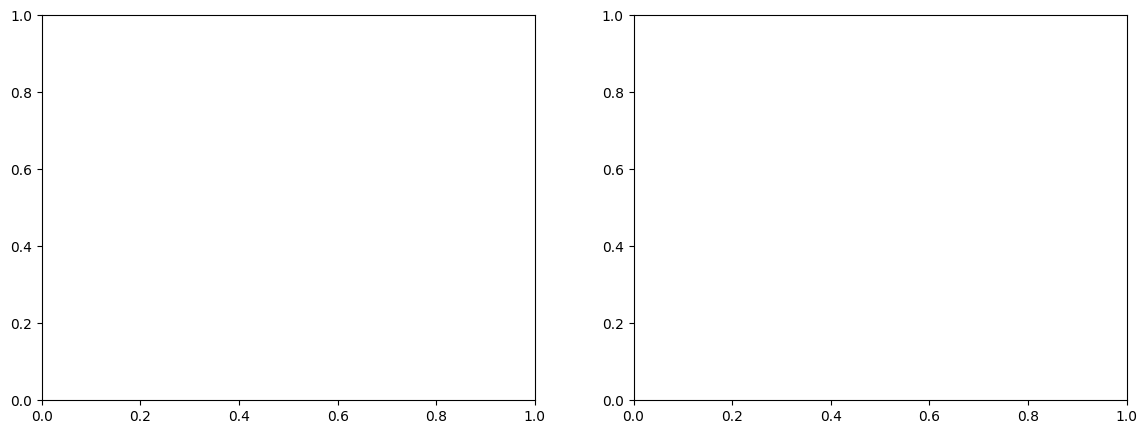

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(history["train_loss"], "b-", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

# Dice curves
val_epochs = list(range(
    CONFIG["val_interval"] - 1,
    len(history["train_loss"]),
    CONFIG["val_interval"]
))
val_epochs = val_epochs[:len(history["val_mean_dice"])]

ax2.plot(val_epochs, history["val_dice_wt"], "r-o", label="WT", markersize=3)
ax2.plot(val_epochs, history["val_dice_tc"], "g-o", label="TC", markersize=3)
ax2.plot(val_epochs, history["val_dice_et"], "y-o", label="ET", markersize=3)
ax2.plot(val_epochs, history["val_mean_dice"], "b-o", label="Mean",
         markersize=3, linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice Score")
ax2.set_title("Validation Dice by Region")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.suptitle(f"Training Curves — {CONFIG['model_name']}", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"],
            f"{CONFIG['model_name']}_training_curves.png"), dpi=150)
plt.show()

### Load Best Model for Evaluation

Load the checkpoint that achieved the highest validation Dice score during training.

In [43]:
checkpoint = torch.load(
    os.path.join(CONFIG["output_dir"], "best_model.pth"),
    map_location=device,
    weights_only=False,
)

# Rebuild model if checkpoint was saved with a different model_name
saved_model_name = checkpoint["config"]["model_name"]
if CONFIG["model_name"] != saved_model_name:
    print(f"Warning: rebuilding model as '{saved_model_name}' to match checkpoint")
    CONFIG["model_name"] = saved_model_name
    model = build_model(CONFIG, device)

model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded best model '{CONFIG['model_name']}' from epoch {checkpoint['epoch']+1} "
      f"(Dice={checkpoint['best_dice']:.4f})")

Loaded best model 'unet' from epoch 88 (Dice=0.8949)


In [44]:
#Fix the HD95.
from scipy.ndimage import distance_transform_edt

def compute_hd95_manual(pred, target):
    """Compute HD95 between two binary masks."""
    pred = pred.astype(bool)
    target = target.astype(bool)
    
    if not pred.any() and not target.any():
        return 0.0
    if not pred.any() or not target.any():
        return np.nan
    
    dt_pred = distance_transform_edt(~pred)
    dt_target = distance_transform_edt(~target)
    
    d1 = dt_target[pred]
    d2 = dt_pred[target]
    
    return np.percentile(np.concatenate([d1, d2]), 95)

### Evaluate on Test Set

Compute **Dice** and **HD95** on the held-out test set using sliding-window inference at full resolution. Results are reported per-subject and aggregated per region.

In [45]:
def evaluate(model, test_loader, config, device):
    """Run evaluation on the test set. Returns per-subject Dice and HD95."""
    model.eval()
    all_dice = []
    all_hd95 = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images = batch["image"].to(device)
            labels = batch["seg"].to(device)

            with torch.amp.autocast("cuda"):
                outputs = sliding_window_inference(
                    inputs=images,
                    roi_size=config["roi_size"],
                    sw_batch_size=2,
                    predictor=model,
                    overlap=0.5,
                )

            preds = torch.argmax(outputs, dim=1)
            pred_regions, seg_regions = compute_brats_regions(preds, labels)

            # Manual dice
            subj_dice = compute_dice_per_channel(pred_regions, seg_regions)
            all_dice.append(subj_dice)

            # Manual HD95 per channel
            pred_np = pred_regions.cpu().numpy()
            seg_np = seg_regions.cpu().numpy()
            subj_hd = []
            for c in range(3):
                subj_hd.append(compute_hd95_manual(pred_np[0, c], seg_np[0, c]))
            all_hd95.append(subj_hd)

    all_dice = np.array(all_dice)
    all_hd95 = np.array(all_hd95)

    regions = ["Whole Tumor (WT)", "Tumor Core (TC)", "Enhancing Tumor (ET)"]

    print("\n" + "=" * 65)
    print(f"TEST SET RESULTS — {config['model_name']}")
    print("=" * 65)
    print(f"{'Region':<25s} {'Dice (mean +/- std)':<22s} {'HD95 (mean +/- std)'}")
    print("-" * 65)
    for i, region in enumerate(regions):
        d_mean, d_std = np.nanmean(all_dice[:, i]), np.nanstd(all_dice[:, i])
        h_mean, h_std = np.nanmean(all_hd95[:, i]), np.nanstd(all_hd95[:, i])
        print(f"{region:<25s} {d_mean:.4f} +/- {d_std:.4f}      "
              f"{h_mean:.2f} +/- {h_std:.2f} mm")

    print(f"\nOverall Mean Dice: {np.nanmean(all_dice):.4f}")
    print("=" * 65)

    return all_dice, all_hd95

test_dice, test_hd95 = evaluate(model, test_loader, CONFIG, device)

Evaluating:   0%|          | 0/126 [00:00<?, ?it/s]


TEST SET RESULTS — unet
Region                    Dice (mean +/- std)    HD95 (mean +/- std)
-----------------------------------------------------------------
Whole Tumor (WT)          0.9312 +/- 0.0544      2.48 +/- 9.53 mm
Tumor Core (TC)           0.9013 +/- 0.1633      2.49 +/- 8.69 mm
Enhancing Tumor (ET)      0.8593 +/- 0.1949      1.78 +/- 4.11 mm

Overall Mean Dice: 0.8972


### Saving Models Result

In [23]:
model_results = {
    "model_name": CONFIG["model_name"],
    "dice_wt": float(np.nanmean(test_dice[:, 0])),
    "dice_tc": float(np.nanmean(test_dice[:, 1])),
    "dice_et": float(np.nanmean(test_dice[:, 2])),
    "hd95_wt": float(np.nanmean(test_hd95[:, 0])),
    "hd95_tc": float(np.nanmean(test_hd95[:, 1])),
    "hd95_et": float(np.nanmean(test_hd95[:, 2])),
}

save_path = os.path.join(CONFIG["output_dir"], f"{CONFIG['model_name']}_results.json")
with open(save_path, "w") as f:
    json.dump(model_results, f, indent=2)
print(f"Results saved to: {save_path}")

Results saved to: ./outputs/unet\unet_results.json


### Boxplot of Test Set Dice Scores

Visualize the distribution of Dice scores across test subjects for each clinical region.

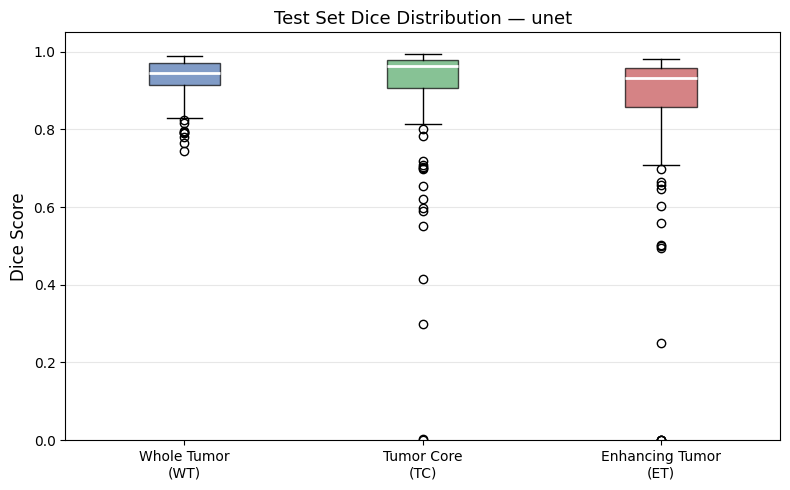

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

regions = ["Whole Tumor\n(WT)", "Tumor Core\n(TC)", "Enhancing Tumor\n(ET)"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

bp = ax.boxplot(
    [test_dice[:, i] for i in range(3)],
    labels=regions,
    patch_artist=True,
    medianprops=dict(color="white", linewidth=2),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Dice Score", fontsize=12)
ax.set_title(f"Test Set Dice Distribution — {CONFIG['model_name']}", fontsize=13)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"],
            f"{CONFIG['model_name']}_dice_boxplot.png"), dpi=150)
plt.show()

### Visual Comparison: Prediction vs Ground Truth

For a few test subjects, overlay the model's prediction and the ground truth on the FLAIR image to visually assess quality.

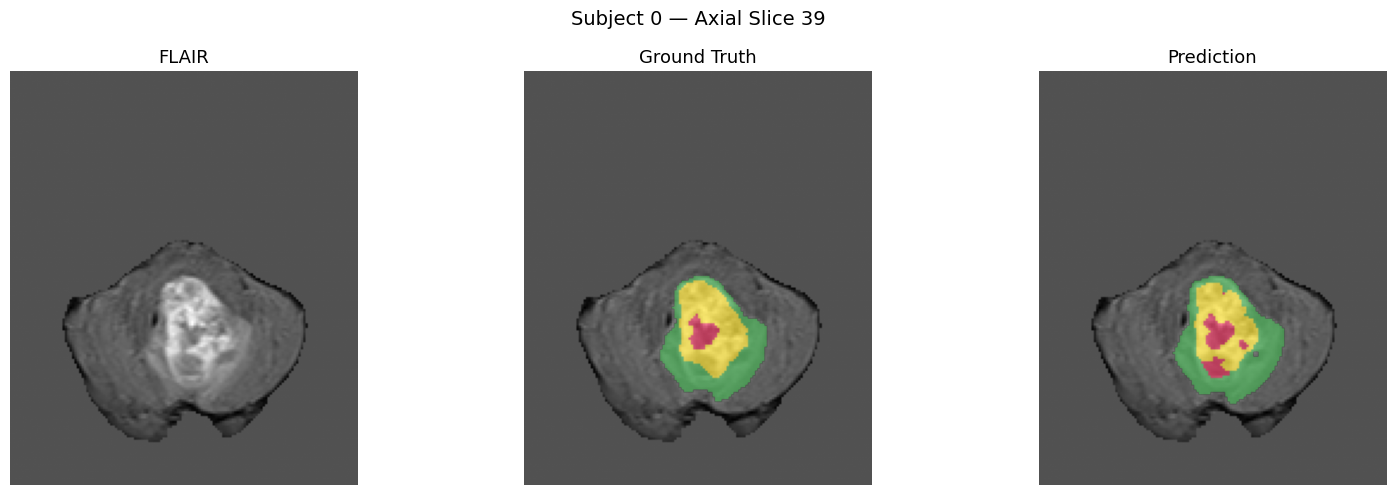

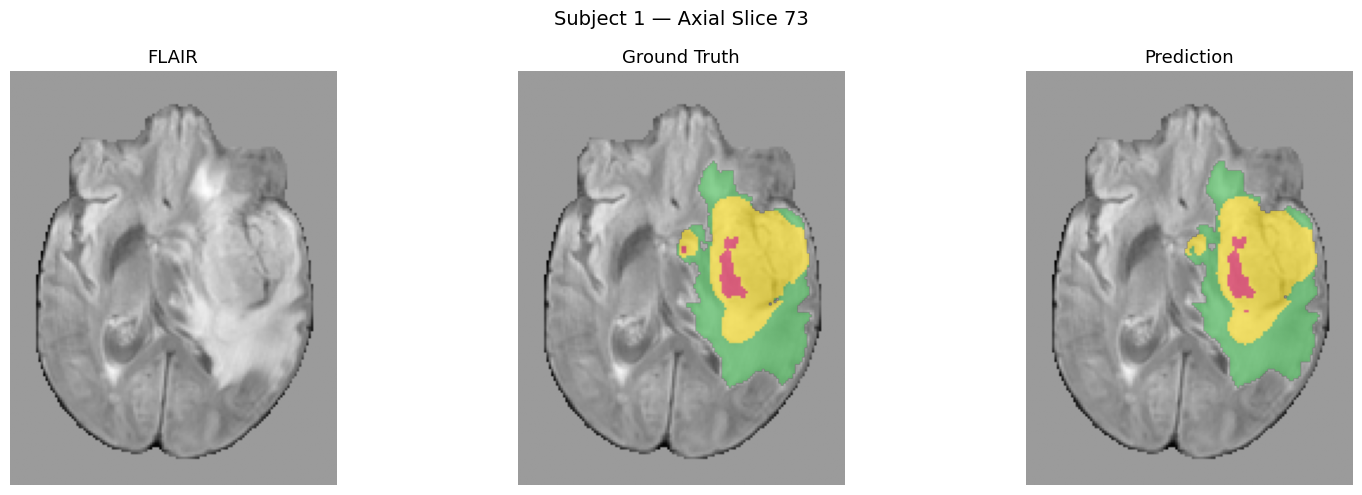

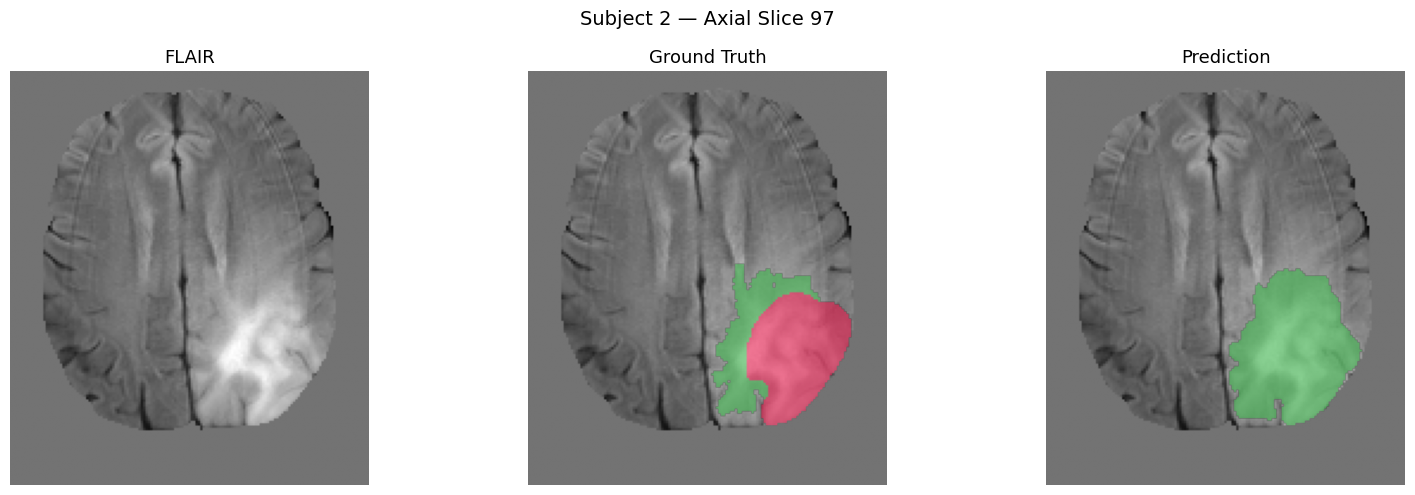

In [25]:
def visualize_prediction(model, dataset, config, device, subject_idx=0):
    """Show FLAIR + ground truth vs FLAIR + prediction side by side."""
    model.eval()
    data = dataset[subject_idx]
    image = data["image"].unsqueeze(0).to(device)  # (1, 4, D, H, W)
    label = data["seg"].cpu().numpy()               # (D, H, W)

    with torch.no_grad(), torch.amp.autocast("cuda"):
        output = sliding_window_inference(
            image, config["roi_size"], sw_batch_size=2,
            predictor=model, overlap=0.5,
        )
    pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()  # (D, H, W)
    flair = data["image"][3].cpu().numpy()  # FLAIR channel

    # Find slice with most tumor in ground truth
    tumor_per_slice = (label > 0).sum(axis=(0, 1))
    best_slice = int(np.argmax(tumor_per_slice))

    seg_cmap = ListedColormap(["none", "#e6194b", "#3cb44b", "#ffe119"])

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # FLAIR only
    axes[0].imshow(flair[:, :, best_slice].T, cmap="gray", origin="lower")
    axes[0].set_title("FLAIR", fontsize=13)
    axes[0].axis("off")

    # Ground truth overlay
    axes[1].imshow(flair[:, :, best_slice].T, cmap="gray", origin="lower")
    gt_m = np.ma.masked_where(label[:, :, best_slice].T == 0,
                               label[:, :, best_slice].T)
    axes[1].imshow(gt_m, cmap=seg_cmap, alpha=0.6, origin="lower", vmin=0, vmax=3)
    axes[1].set_title("Ground Truth", fontsize=13)
    axes[1].axis("off")

    # Prediction overlay
    axes[2].imshow(flair[:, :, best_slice].T, cmap="gray", origin="lower")
    pr_m = np.ma.masked_where(pred[:, :, best_slice].T == 0,
                               pred[:, :, best_slice].T)
    axes[2].imshow(pr_m, cmap=seg_cmap, alpha=0.6, origin="lower", vmin=0, vmax=3)
    axes[2].set_title("Prediction", fontsize=13)
    axes[2].axis("off")

    plt.suptitle(f"Subject {subject_idx} — Axial Slice {best_slice}", fontsize=14)
    plt.tight_layout()
    plt.show()


# Visualize first 3 test subjects
for i in range(min(3, len(test_ds))):
    visualize_prediction(model, test_ds, CONFIG, device, subject_idx=i)

### Multi-Plane Visualization (Axial / Sagittal / Coronal)

Show the prediction from all three anatomical planes for a comprehensive 3D assessment.

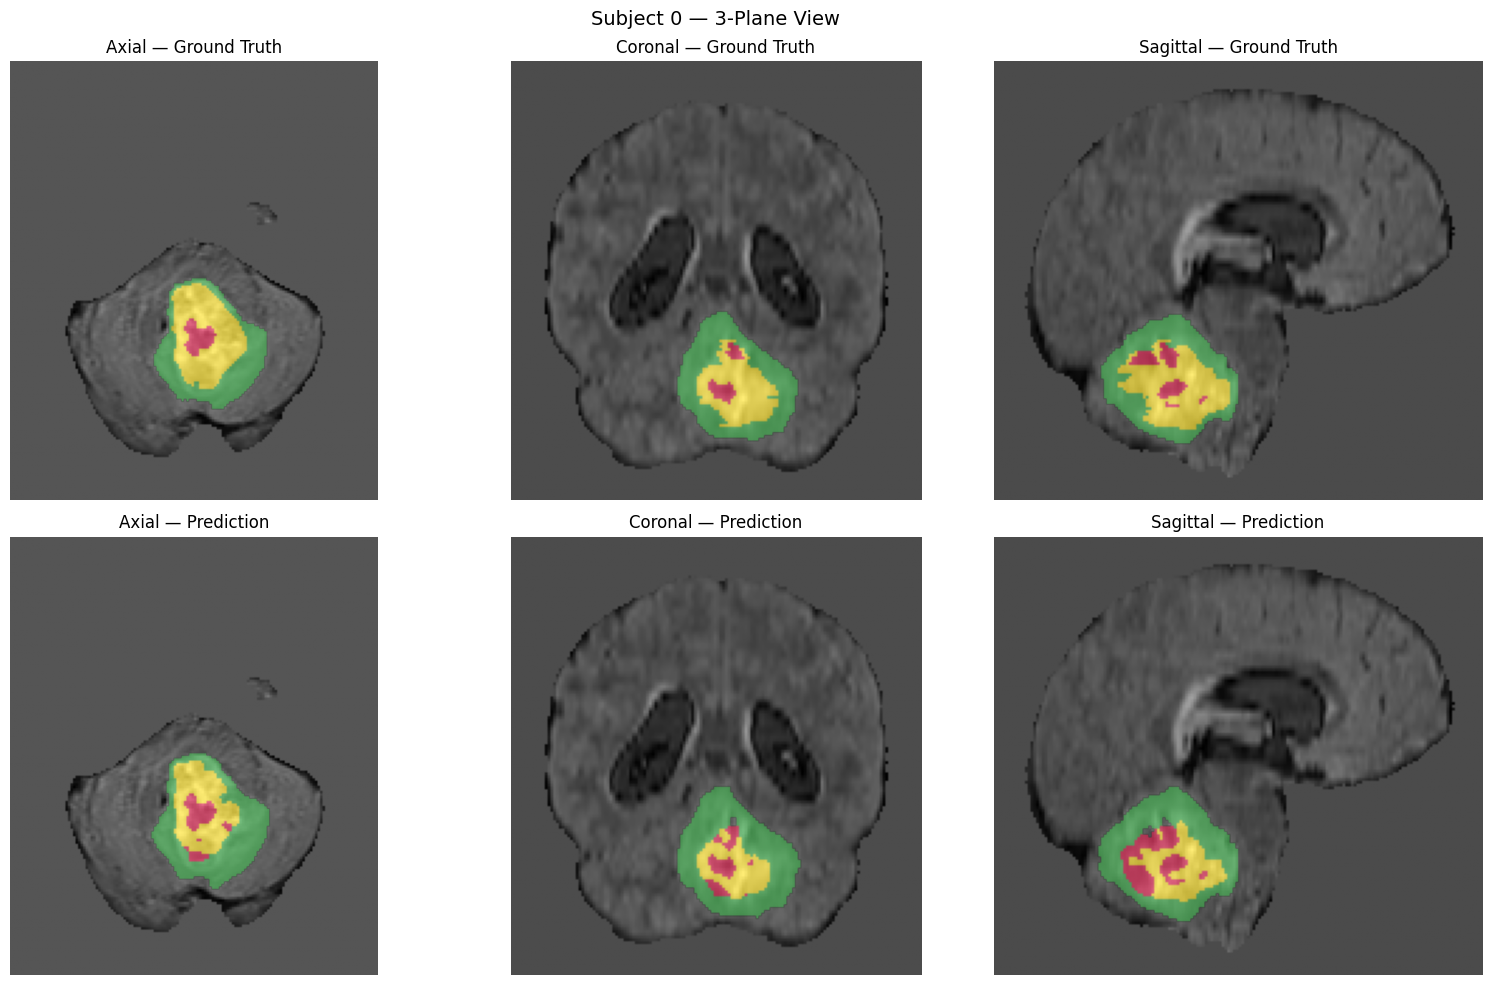

In [26]:
def visualize_3_planes(model, dataset, config, device, subject_idx=0):
    """Show prediction overlays in axial, sagittal, and coronal planes."""
    model.eval()
    data = dataset[subject_idx]
    image = data["image"].unsqueeze(0).to(device)
    label = data["seg"].cpu().numpy()

    with torch.no_grad(), torch.amp.autocast("cuda"):
        output = sliding_window_inference(
            image, config["roi_size"], sw_batch_size=2,
            predictor=model, overlap=0.5,
        )
    pred = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
    flair = data["image"][3].cpu().numpy()

    seg_cmap = ListedColormap(["none", "#e6194b", "#3cb44b", "#ffe119"])

    # Find center of tumor mass
    tumor_coords = np.argwhere(label > 0)
    if len(tumor_coords) > 0:
        center = tumor_coords.mean(axis=0).astype(int)
    else:
        center = np.array(label.shape) // 2

    planes = {
        "Axial":    (lambda f, s: (f[:, :, center[2]].T, s[:, :, center[2]].T)),
        "Coronal":  (lambda f, s: (f[:, center[1], :].T, s[:, center[1], :].T)),
        "Sagittal": (lambda f, s: (f[center[0], :, :].T, s[center[0], :, :].T)),
    }

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    for col, (plane_name, slicer) in enumerate(planes.items()):
        flair_sl, gt_sl = slicer(flair, label)
        _, pred_sl = slicer(flair, pred)

        # Ground truth row
        axes[0, col].imshow(flair_sl, cmap="gray", origin="lower")
        gt_m = np.ma.masked_where(gt_sl == 0, gt_sl)
        axes[0, col].imshow(gt_m, cmap=seg_cmap, alpha=0.6, origin="lower",
                            vmin=0, vmax=3)
        axes[0, col].set_title(f"{plane_name} — Ground Truth", fontsize=12)
        axes[0, col].axis("off")

        # Prediction row
        axes[1, col].imshow(flair_sl, cmap="gray", origin="lower")
        pr_m = np.ma.masked_where(pred_sl == 0, pred_sl)
        axes[1, col].imshow(pr_m, cmap=seg_cmap, alpha=0.6, origin="lower",
                            vmin=0, vmax=3)
        axes[1, col].set_title(f"{plane_name} — Prediction", fontsize=12)
        axes[1, col].axis("off")

    plt.suptitle(f"Subject {subject_idx} — 3-Plane View", fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_3_planes(model, test_ds, CONFIG, device, subject_idx=0)

---
## Model Comparison

After training all three models, load results from their JSON files and generate comparison charts.

Loaded: 3D U-Net
Not found: Attention U-Net (not trained yet?)
Not found: Swin UNETR (not trained yet?)

MODEL COMPARISON
          Dice WT  Dice TC  Dice ET  Dice Mean  HD95 WT  HD95 TC  HD95 ET
Model                                                                    
3D U-Net   0.9312   0.9013   0.8593     0.8972   4.7217      NaN      NaN


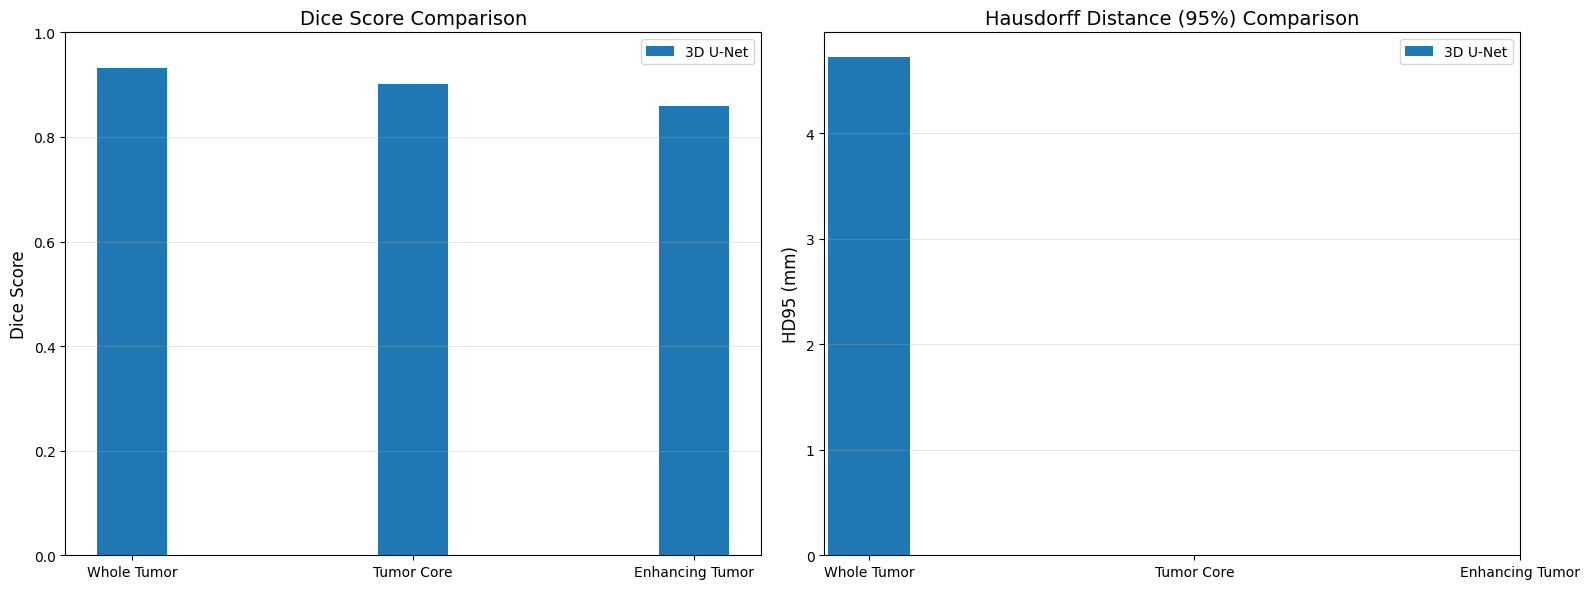


Best model: 3D U-Net (Mean Dice = 0.8972)


In [27]:
# ── Load results from all trained models ──────────────────────
model_dirs = {
    "3D U-Net": "./outputs/unet",
    "Attention U-Net": "./outputs/attention_unet",
    "Swin UNETR": "./outputs/swin_unetr",
}

results = {}
for display_name, dir_path in model_dirs.items():
    json_files = glob.glob(os.path.join(dir_path, "*_results.json"))
    if json_files:
        with open(json_files[0], "r") as f:
            results[display_name] = json.load(f)
        print(f"Loaded: {display_name}")
    else:
        print(f"Not found: {display_name} (not trained yet?)")

if len(results) == 0:
    print("\nNo results found. Train at least one model first.")
else:
    # ── Comparison table ──────────────────────────────────────
    rows = []
    for name, r in results.items():
        rows.append({
            "Model": name,
            "Dice WT": r["dice_wt"],
            "Dice TC": r["dice_tc"],
            "Dice ET": r["dice_et"],
            "Dice Mean": np.mean([r["dice_wt"], r["dice_tc"], r["dice_et"]]),
            "HD95 WT": r["hd95_wt"],
            "HD95 TC": r["hd95_tc"],
            "HD95 ET": r["hd95_et"],
        })
    df = pd.DataFrame(rows).set_index("Model")
    print("\n" + "=" * 80)
    print("MODEL COMPARISON")
    print("=" * 80)
    print(df.round(4).to_string())
    print("=" * 80)

    # ── Bar chart ─────────────────────────────────────────────
    models = list(results.keys())
    region_keys = ["WT", "TC", "ET"]
    x = np.arange(len(region_keys))
    width = 0.25

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    for i, mname in enumerate(models):
        r = results[mname]
        dice_vals = [r["dice_wt"], r["dice_tc"], r["dice_et"]]
        ax1.bar(x + i * width, dice_vals, width, label=mname)

    ax1.set_ylabel("Dice Score", fontsize=12)
    ax1.set_title("Dice Score Comparison", fontsize=14)
    ax1.set_xticks(x + width * (len(models) - 1) / 2)
    ax1.set_xticklabels(["Whole Tumor", "Tumor Core", "Enhancing Tumor"])
    ax1.legend()
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3, axis="y")

    for i, mname in enumerate(models):
        r = results[mname]
        hd_vals = [r["hd95_wt"], r["hd95_tc"], r["hd95_et"]]
        ax2.bar(x + i * width, hd_vals, width, label=mname)

    ax2.set_ylabel("HD95 (mm)", fontsize=12)
    ax2.set_title("Hausdorff Distance (95%) Comparison", fontsize=14)
    ax2.set_xticks(x + width * (len(models) - 1) / 2)
    ax2.set_xticklabels(["Whole Tumor", "Tumor Core", "Enhancing Tumor"])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("./outputs/model_comparison.png", dpi=150)
    plt.show()

    # ── Pick best model ───────────────────────────────────────
    best_name = max(results, key=lambda n: np.mean([
        results[n]["dice_wt"], results[n]["dice_tc"], results[n]["dice_et"]]))
    best_dice = np.mean([results[best_name]["dice_wt"],
                         results[best_name]["dice_tc"],
                         results[best_name]["dice_et"]])
    print(f"\nBest model: {best_name} (Mean Dice = {best_dice:.4f})")